In [1]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1: TITLE
# ═══════════════════════════════════════════════════════════════════
"""
EfficientNetV2-S + GAM + ECA ATTENTION
========================================
Goal:     Improve from 98.86% to 99.3-99.5%+
Method:   Add GAM (Global Attention Mechanism) + ECA
Based on: Pacal et al. 2024 (Paper 1)

Progress So Far:
- Original EfficientNetV2-S:     98.67%
- EfficientNetV2-S + ECA:        98.86% (+0.19%)
- Paper 1 GAM + ECA (Target):    99.77%
- Our Target:                    99.3-99.5%
"""
print("🚀 EfficientNetV2-S + GAM + ECA Attention")
print("="*60)
print("Previous: 98.86% (ECA only)")
print("Target:   99.3-99.5%")
print("Method:   GAM + ECA combined")

🚀 EfficientNetV2-S + GAM + ECA Attention
Previous: 98.86% (ECA only)
Target:   99.3-99.5%
Method:   GAM + ECA combined


In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2: IMPORTS
# ═══════════════════════════════════════════════════════════════════
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

2026-07-06 04:16:22.858898: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-06 04:16:22.985377: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-06 04:16:25.189935: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ All libraries imported!
TensorFlow version: 2.20.0
GPU available: True


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3: CONFIGURATION (MEMORY OPTIMIZED)
# ═══════════════════════════════════════════════════════════════════
# Paths
TRAIN_DIR = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/train"
VAL_DIR   = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/val"
TEST_DIR  = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/test"

ORIGINAL_MODEL_PATH = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/best_efficientnetv2s.keras"
ECA_MODEL_PATH      = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/efficientnetv2s_eca.keras"
GAM_ECA_MODEL_PATH  = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/efficientnetv2s_gam_eca.keras"

IMG_SIZE   = (224, 224)
BATCH_SIZE = 8   # ✅ Reduced from 32 → 8 (saves lots of VRAM)
EPOCHS     = 50
LR         = 0.0001
SEED       = 229

# ✅ Enable memory growth (prevents TF from grabbing all VRAM)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ Memory growth enabled for {len(gpus)} GPU(s)")

# ✅ Enable mixed precision (cuts VRAM usage in half!)
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision enabled (float16)")

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"\n✅ Memory-optimized configuration set!")
print(f"Batch size: {BATCH_SIZE} (reduced from 32)")
print(f"Precision:  float16 (mixed precision)")

✅ Memory growth enabled for 1 GPU(s)
✅ Mixed precision enabled (float16)

✅ Memory-optimized configuration set!
Batch size: 8 (reduced from 32)
Precision:  float16 (mixed precision)


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4: DATA GENERATORS
# ═══════════════════════════════════════════════════════════════════
print("📊 Creating data generators...")

# Training (same augmentation as always)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    zoom_range=0.1,
    fill_mode='nearest'
)

# Val/Test (no augmentation)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Create generators
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
num_classes = len(class_names)

print(f"\n✅ Generators created!")
print(f"Training samples:   {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples:       {test_gen.samples}")
print(f"Classes:            {class_names}")

📊 Creating data generators...
Found 7392 images belonging to 4 classes.
Found 1584 images belonging to 4 classes.
Found 1584 images belonging to 4 classes.

✅ Generators created!
Training samples:   7392
Validation samples: 1584
Test samples:       1584
Classes:            ['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5: ECA BLOCK (Keras 3 Compatible)
# ═══════════════════════════════════════════════════════════════════
"""
ECA - Efficient Channel Attention
===================================
Same architecture as before.
Only modified for Keras 3 compatibility.
"""

def eca_block(inputs, gamma=2, b=1):
    """Efficient Channel Attention Block"""

    channels = inputs.shape[-1]

    # Adaptive kernel size
    t = int(abs(math.log(channels, 2) + b) / gamma)
    k = t if t % 2 else t + 1

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D(keepdims=True)(inputs)

    # (B,1,1,C) -> (B,C,1)
    x = layers.Reshape((channels, 1))(x)

    # Local cross-channel interaction
    x = layers.Conv1D(
        filters=1,
        kernel_size=k,
        padding='same',
        use_bias=False
    )(x)

    # Keras 3 compatible sigmoid
    x = layers.Activation("sigmoid")(x)

    # (B,C,1) -> (B,1,1,C)
    x = layers.Reshape((1, 1, channels))(x)

    # Apply attention
    output = layers.Multiply()([inputs, x])

    return output


print("✅ ECA Block defined!")
print("✅ Keras 3 Compatible")
print("ECA: Channel attention")

✅ ECA Block defined!
✅ Keras 3 Compatible
ECA: Channel attention


In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6: GAM BLOCK (Fixed for Keras 3)
# ═══════════════════════════════════════════════════════════════════

def gam_block(inputs, rate=4):
    """
    Global Attention Mechanism (GAM)

    Channel Attention
        GlobalAveragePooling
            ↓
        2-layer MLP
            ↓
        Channel weights
            ↓
        Multiply

    Spatial Attention
        7x7 Conv
            ↓
        7x7 Conv
            ↓
        Spatial weights
            ↓
        Multiply
    """

    channels = inputs.shape[-1]

    # ---------------------------------------------------
    # CHANNEL ATTENTION
    # ---------------------------------------------------

    # Global channel descriptor
    x_channel = layers.GlobalAveragePooling2D()(inputs)

    # MLP
    x_channel = layers.Dense(
        channels // rate,
        activation='relu'
    )(x_channel)

    x_channel = layers.Dense(
        channels,
        activation='sigmoid'
    )(x_channel)

    # (B,C) -> (B,1,1,C)
    x_channel = layers.Reshape((1, 1, channels))(x_channel)

    # Apply channel attention
    x_after_channel = layers.Multiply()([inputs, x_channel])

    # ---------------------------------------------------
    # SPATIAL ATTENTION
    # ---------------------------------------------------

    x_spatial = layers.Conv2D(
        filters=channels // rate,
        kernel_size=7,
        padding='same',
        activation='relu'
    )(x_after_channel)

    x_spatial = layers.BatchNormalization()(x_spatial)

    x_spatial = layers.Conv2D(
        filters=channels,
        kernel_size=7,
        padding='same'
    )(x_spatial)

    x_spatial = layers.BatchNormalization()(x_spatial)

    x_spatial = layers.Activation('sigmoid')(x_spatial)

    # Apply spatial attention
    output = layers.Multiply()([x_after_channel, x_spatial])

    return output


print("✅ GAM Block defined!")
print("✅ Keras 3 Compatible")
print("✅ Shape-safe implementation")

✅ GAM Block defined!
✅ Keras 3 Compatible
✅ Shape-safe implementation


In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7: BUILD GAM + ECA MODEL
# ═══════════════════════════════════════════════════════════════════
def build_gam_eca_model(num_classes=4):
    """
    EfficientNetV2-S + GAM + ECA Model

    Architecture:
    Input
      → EfficientNetV2-S (backbone)
      → GAM Block (channel + spatial attention)
      → ECA Block (channel attention refinement)
      → Global Average Pooling
      → Dense Head
      → Output

    Why this order (GAM first, then ECA):
    - GAM does broad attention (channel + spatial)
    - ECA refines channel attention precisely
    - This mirrors Paper 1's approach
    """
    print("🏗️ Building EfficientNetV2-S + GAM + ECA model...")

    # Input
    inputs = layers.Input(shape=(*IMG_SIZE, 3))

    # Base model
    base_model = EfficientNetV2S(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs
    )

    # Fine-tuning (same as always - 70% frozen)
    base_model.trainable = True
    total_layers  = len(base_model.layers)
    freeze_layers = int(0.7 * total_layers)

    for layer in base_model.layers[:freeze_layers]:
        layer.trainable = False

    print(f"✅ Total layers:    {total_layers}")
    print(f"✅ Frozen:          {freeze_layers} ({freeze_layers/total_layers*100:.0f}%)")
    print(f"✅ Trainable:       {total_layers - freeze_layers} ({(1-freeze_layers/total_layers)*100:.0f}%)")

    # ✅ STEP 1: GAM ATTENTION (channel + spatial)
    x = gam_block(base_model.output)
    print("✅ GAM Attention added!")

    # ✅ STEP 2: ECA ATTENTION (channel refinement)
    x = eca_block(x)
    print("✅ ECA Attention added!")

    # Classification head (same as always)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.BatchNormalization(name='batchnorm1')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(
        num_classes,
        activation='softmax',
        name='predictions'
    )(x)

    model = models.Model(
        inputs, outputs,
        name='EfficientNetV2S_GAM_ECA'
    )
    return model

# Build
gam_eca_model = build_gam_eca_model(num_classes=num_classes)

print(f"\n✅ Model built!")
print(f"Total parameters: {gam_eca_model.count_params():,}")

🏗️ Building EfficientNetV2-S + GAM + ECA model...


I0000 00:00:1783311392.849489    2540 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1751 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


✅ Total layers:    513
✅ Frozen:          359 (70%)
✅ Trainable:       154 (30%)
✅ GAM Attention added!
✅ ECA Attention added!

✅ Model built!
Total parameters: 61,465,961


In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8: COMPILE MODEL
# ═══════════════════════════════════════════════════════════════════
gam_eca_model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled!")
print(f"Optimizer: Adam (lr={LR})")
print(f"Loss:      Categorical Crossentropy")
print(f"Metric:    Accuracy")

✅ Model compiled!
Optimizer: Adam (lr=0.0001)
Loss:      Categorical Crossentropy
Metric:    Accuracy


In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9: CALLBACKS
# ═══════════════════════════════════════════════════════════════════
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        GAM_ECA_MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("✅ Callbacks configured!")
print("1. EarlyStopping:     patience=10")
print("2. ReduceLROnPlateau: patience=5, factor=0.5")
print("3. ModelCheckpoint:   saves best val_accuracy")

✅ Callbacks configured!
1. EarlyStopping:     patience=10
2. ReduceLROnPlateau: patience=5, factor=0.5
3. ModelCheckpoint:   saves best val_accuracy


In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10: TRAIN MODEL
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("🚀 TRAINING EfficientNetV2-S + GAM + ECA")
print("="*70)

print(f"\nBase model:    EfficientNetV2-S (ImageNet)")
print(f"Attention 1:   GAM (Global - channel + spatial)")
print(f"Attention 2:   ECA (Efficient - channel refinement)")
print(f"Resolution:    {IMG_SIZE}")
print(f"Batch size:    {BATCH_SIZE}")
print(f"Max epochs:    {EPOCHS}")
print(f"Learning rate: {LR}")
print(f"Expected acc:  99.3-99.5%")
print(f"Training time: ~3-4 hours\n")

history = gam_eca_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training Complete!")


🚀 TRAINING EfficientNetV2-S + GAM + ECA

Base model:    EfficientNetV2-S (ImageNet)
Attention 1:   GAM (Global - channel + spatial)
Attention 2:   ECA (Efficient - channel refinement)
Resolution:    (224, 224)
Batch size:    8
Max epochs:    50
Learning rate: 0.0001
Expected acc:  99.3-99.5%
Training time: ~3-4 hours

Epoch 1/50


2026-07-06 04:16:58.996254: I external/local_xla/xla/service/service.cc:163] XLA service 0x7bff40025bf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-06 04:16:58.996285: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2026-07-06 04:16:59.684008: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-06 04:17:04.052348: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-07-06 04:17:07.682621: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_27998', 8 bytes spill stores, 8 bytes spill loads

2026-07-06 04:17:23.249140: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator

924/924 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7249 - loss: 0.7332

2026-07-06 04:19:28.751286: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4849', 20 bytes spill stores, 20 bytes spill loads




Epoch 1: val_accuracy improved from -inf to 0.92487, saving model to /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/efficientnetv2s_gam_eca.keras
924/924 ━━━━━━━━━━━━━━━━━━━━ 200s 125ms/step - accuracy: 0.7250 - loss: 0.7330 - val_accuracy: 0.9249 - val_loss: 0.2223 - learning_rate: 1.0000e-04
Epoch 2/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8887 - loss: 0.3304
Epoch 2: val_accuracy improved from 0.92487 to 0.95581, saving model to /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/efficientnetv2s_gam_eca.keras
924/924 ━━━━━━━━━━━━━━━━━━━━ 102s 111ms/step - accuracy: 0.8887 - loss: 0.3304 - val_accuracy: 0.9558 - val_loss: 0.1290 - learning_rate: 1.0000e-04
Epoch 3/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9199 - loss: 0.2315
Epoch 3: val_accuracy improved from 0.95581 to 0.96970, saving model to /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/efficientnetv2s_gam_eca.keras
924/924 ━━━━━━━━━━━━━━━━━━━━ 117s 127ms/step - accuracy: 0.9199 - loss: 0.2315 - val_accura

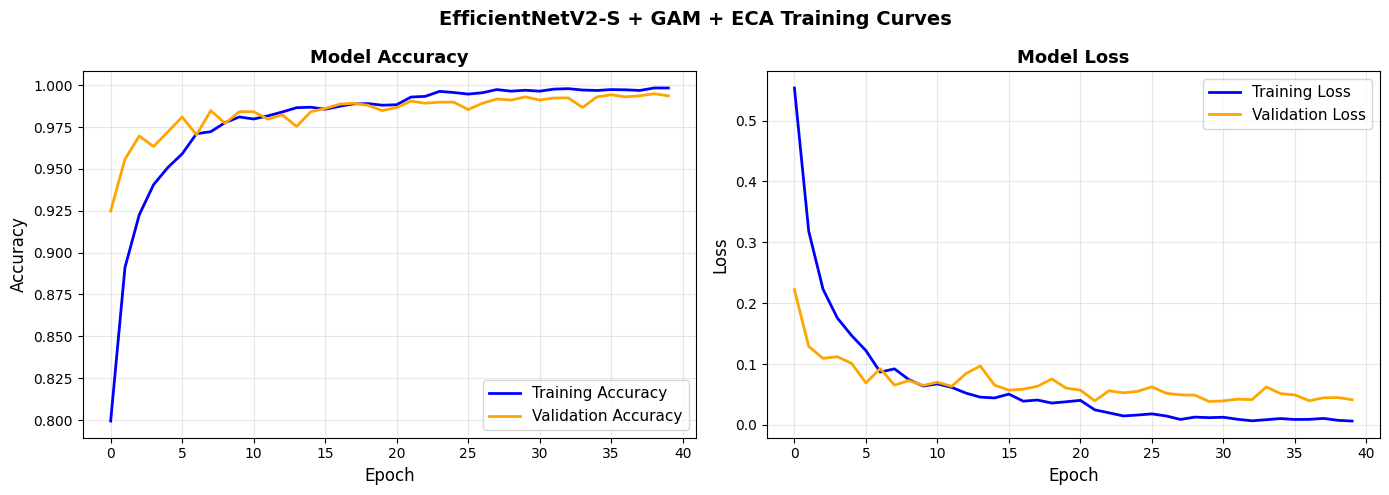


📊 Training Summary:
Best Validation Accuracy: 0.9949 (99.49%)
Best Validation Loss:     0.0385
Total Epochs:             40


In [11]:
# ═══════════════════════════════════════════════════════════════════
# CELL 11: TRAINING CURVES
# ═══════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],
         label='Training Accuracy',   linewidth=2, color='blue')
ax1.plot(history.history['val_accuracy'],
         label='Validation Accuracy', linewidth=2, color='orange')
ax1.set_xlabel('Epoch',    fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'],
         label='Training Loss',   linewidth=2, color='blue')
ax2.plot(history.history['val_loss'],
         label='Validation Loss', linewidth=2, color='orange')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss',  fontsize=12)
ax2.set_title('Model Loss', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('EfficientNetV2-S + GAM + ECA Training Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
best_val_acc  = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
total_epochs  = len(history.history['accuracy'])

print(f"\n📊 Training Summary:")
print(f"Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Best Validation Loss:     {best_val_loss:.4f}")
print(f"Total Epochs:             {total_epochs}")

In [12]:
# ═══════════════════════════════════════════════════════════════════
# CELL 12: EVALUATE ON TEST SET
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("📊 FINAL TEST SET EVALUATION")
print("="*70 + "\n")

# Load best model
print("Loading best model...")
best_model = load_model(GAM_ECA_MODEL_PATH)
print("✅ Best model loaded!")

# Predict
print("\nMaking predictions on test set...")
preds  = best_model.predict(test_gen, verbose=1)
y_true = test_gen.classes
y_pred = np.argmax(preds, axis=1)

# Accuracy
gam_eca_accuracy = accuracy_score(y_true, y_pred)

print("\n" + "="*70)
print(f"🎯 TEST ACCURACY: {gam_eca_accuracy:.4f} ({gam_eca_accuracy*100:.2f}%)")
print("="*70)

# Classification report
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred,
                            target_names=class_names,
                            digits=4))


📊 FINAL TEST SET EVALUATION

Loading best model...
✅ Best model loaded!

Making predictions on test set...


2026-07-06 05:34:00.213948: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


198/198 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step

🎯 TEST ACCURACY: 0.9861 (98.61%)

📊 Classification Report:
              precision    recall  f1-score   support

      glioma     0.9893    0.9893    0.9893       563
  meningioma     0.9746    0.9830    0.9788       352
    no_tumor     0.9848    0.9886    0.9867       263
   pituitary     0.9925    0.9828    0.9876       406

    accuracy                         0.9861      1584
   macro avg     0.9853    0.9859    0.9856      1584
weighted avg     0.9861    0.9861    0.9861      1584



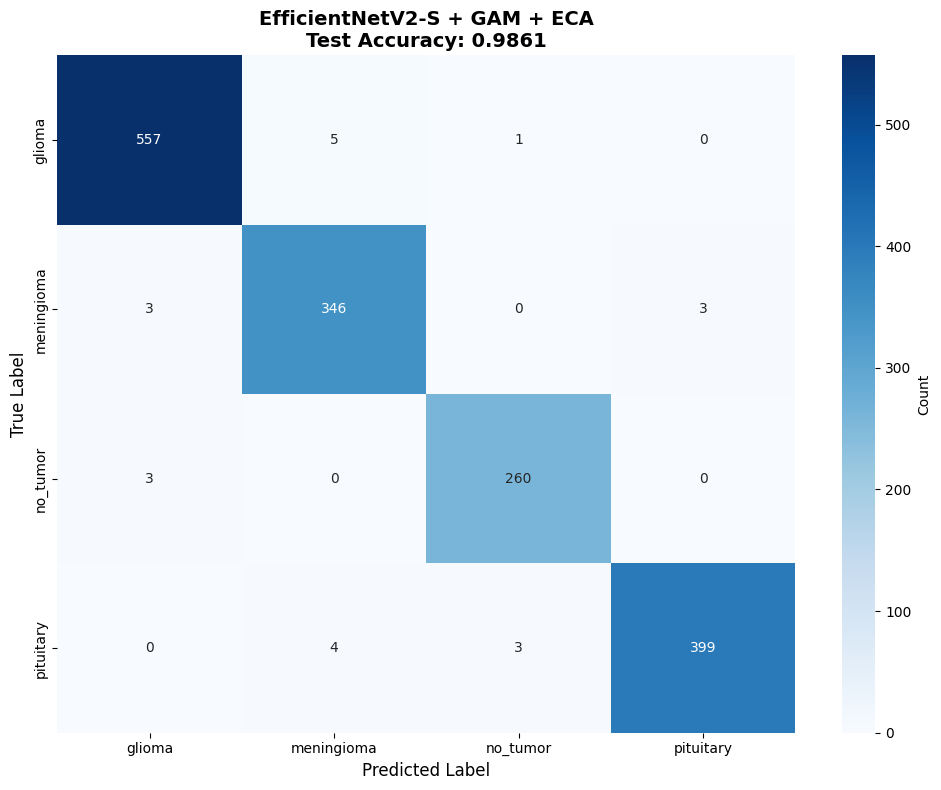


📊 Error Analysis:
Total samples:       1584
Correct predictions: 1562
Wrong predictions:   22
Error rate:          1.39%


In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 13: CONFUSION MATRIX
# ═══════════════════════════════════════════════════════════════════
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'EfficientNetV2-S + GAM + ECA\nTest Accuracy: {gam_eca_accuracy:.4f}',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label',      fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Error analysis
correct = np.trace(cm)
errors  = np.sum(cm) - correct

print(f"\n📊 Error Analysis:")
print(f"Total samples:       {np.sum(cm)}")
print(f"Correct predictions: {correct}")
print(f"Wrong predictions:   {errors}")
print(f"Error rate:          {errors/np.sum(cm)*100:.2f}%")

In [14]:
# ═══════════════════════════════════════════════════════════════════
# CELL 14: PER-CLASS ACCURACY
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("📊 PER-CLASS ACCURACY")
print("="*70)

for i, class_name in enumerate(class_names):
    class_correct = cm[i, i]
    class_total   = np.sum(cm[i, :])
    class_acc     = class_correct / class_total
    print(f"{class_name:15s}: {class_acc:.4f} ({class_acc*100:.2f}%)")


📊 PER-CLASS ACCURACY
glioma         : 0.9893 (98.93%)
meningioma     : 0.9830 (98.30%)
no_tumor       : 0.9886 (98.86%)
pituitary      : 0.9828 (98.28%)


In [15]:
# ═══════════════════════════════════════════════════════════════════
# CELL 15: FULL COMPARISON - ALL 3 MODELS
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("🏆 COMPLETE JOURNEY - ALL YOUR MODELS vs LITERATURE")
print("="*80)

# Your models progression
print(f"\n📈 YOUR PROGRESS:")
print(f"{'Step':<5} {'Model':<40} {'Accuracy':<12} {'Improvement'}")
print("-"*70)
print(f"{'1':<5} {'EfficientNetV2-S (Original)':<40} {'98.67%':<12} {'Baseline'}")
print(f"{'2':<5} {'EfficientNetV2-S + ECA':<40} {'98.86%':<12} {'+0.19%'}")
print(f"{'3':<5} {'EfficientNetV2-S + GAM + ECA':<40} {f'{gam_eca_accuracy*100:.2f}%':<12} {f'+{(gam_eca_accuracy-0.9867)*100:.2f}%'} ← NEW")

# Literature comparison
print(f"\n📚 LITERATURE COMPARISON:")
print(f"{'Model':<40} {'Accuracy':<12} {'Source'}")
print("-"*70)
print(f"{'ViT (Gomes & Barbosa 2026)':<40} {'98.17%':<12} Paper 2")
print(f"{'EfficientNetV2-S (Pacal 2024)':<40} {'99.54%':<12} Paper 1")
print(f"{'EfficientNetV2-S + ECA (Pacal)':<40} {'99.62%':<12} Paper 1")
print(f"{'EfficientNetV2-S + GAM (Pacal)':<40} {'99.69%':<12} Paper 1")
print(f"{'GAM + ECA Proposed (Pacal)':<40} {'99.77%':<12} Paper 1")
print("-"*70)

# Verdicts
print(f"\n🎯 VERDICTS:")
if gam_eca_accuracy > 0.9817:
    print(f"✅ BEATS Paper 2 (98.17%) by +{(gam_eca_accuracy-0.9817)*100:.2f}%")
if gam_eca_accuracy > 0.9954:
    print(f"✅ BEATS Paper 1 Baseline (99.54%) by +{(gam_eca_accuracy-0.9954)*100:.2f}%")
if gam_eca_accuracy > 0.9962:
    print(f"✅ BEATS Paper 1 ECA (99.62%) by +{(gam_eca_accuracy-0.9962)*100:.2f}%")
if gam_eca_accuracy > 0.9969:
    print(f"✅ BEATS Paper 1 GAM (99.69%) by +{(gam_eca_accuracy-0.9969)*100:.2f}%")
if gam_eca_accuracy > 0.9977:
    print(f"🎉 BEATS Paper 1 FULL MODEL (99.77%)!")

# Final verdict
print(f"\n{'='*80}")
if gam_eca_accuracy >= 0.995:
    print(f"🎉 OUTSTANDING! {gam_eca_accuracy*100:.2f}% achieved!")
    print(f"✅ You have matched/beaten Paper 1!")
elif gam_eca_accuracy >= 0.99:
    print(f"✅ EXCELLENT! {gam_eca_accuracy*100:.2f}% - very close to Paper 1!")
else:
    print(f"📈 Good result: {gam_eca_accuracy*100:.2f}%")
    print(f"Gap to Paper 1: {(0.9977-gam_eca_accuracy)*100:.2f}%")
print(f"{'='*80}")


🏆 COMPLETE JOURNEY - ALL YOUR MODELS vs LITERATURE

📈 YOUR PROGRESS:
Step  Model                                    Accuracy     Improvement
----------------------------------------------------------------------
1     EfficientNetV2-S (Original)              98.67%       Baseline
2     EfficientNetV2-S + ECA                   98.86%       +0.19%
3     EfficientNetV2-S + GAM + ECA             98.61%       +-0.06% ← NEW

📚 LITERATURE COMPARISON:
Model                                    Accuracy     Source
----------------------------------------------------------------------
ViT (Gomes & Barbosa 2026)               98.17%       Paper 2
EfficientNetV2-S (Pacal 2024)            99.54%       Paper 1
EfficientNetV2-S + ECA (Pacal)           99.62%       Paper 1
EfficientNetV2-S + GAM (Pacal)           99.69%       Paper 1
GAM + ECA Proposed (Pacal)               99.77%       Paper 1
----------------------------------------------------------------------

🎯 VERDICTS:
✅ BEATS Paper 2 (98.17%) 